In [1]:
from swemnics import solvers as Solvers
from swemnics.adcirc_problem import ADCIRCProblem
from mpi4py import MPI
import numpy as np
import matplotlib.pyplot as plt

# from swemnics.forcing import GriddedForcing
from swemnics.constants import R
import time
import argparse as ap

comm = MPI.COMM_WORLD
rank = comm.Get_rank()


In [2]:



print("Running shinnecock")
dt = 600
t_f = 5 * 24 * 3600 - 3600
nt = int(t_f / dt)
is_spherical = True
wd = 1.5
bath_adjust = 0 if wd else 4.0
dramp = 2.0
prob = ADCIRCProblem(
    adios_file="data/shinnecock_inlet",
    spherical=is_spherical,
    solution_var="h",
    friction_law="mannings",
    wd=wd,
    wd_alpha=1.5,
    # forcing=GriddedForcing("data/shinnecock_forcing.hdf5"),
    dt=dt,
    bathy_adjustment=bath_adjust,
    nt=nt,
    dramp=dramp,
)
p_degree = 1
rel_toleran = 1e-5
abs_toleran = 1e-6
max_iter = 10
relax_param = 1.0
# time series output

# expected in Lon/Lat
# the boundary node maybe
# stations = np.array([[-72.9240934829 ,  40.7116348764, 0.0]])
# the node in middle of channel
stations = np.array([[-72.476519, 40.840969, 0.0]])
# not sure where this node is
# stations = np.array([[-72.0576782709, 40.9902316949, 0.0]])
# transform to projected

stations = np.deg2rad(stations)
# use the equator as a reference point
lat0 = 35
stations[:, 0] *= R * np.cos(np.deg2rad(lat0))
stations[:, 1] *= R
print(stations)

# create solver object
theta = 1
# first number is continuity, second is momentum
p_degree = [1, 1]
name = "DG"
# supg
if name == "SUPG":
    solver = Solvers.SUPGImplicit(prob, theta, p_degree=p_degree)
elif name == "DG":
    # dg DGImplicit
    solver = Solvers.DGImplicit(prob, theta, p_degree=p_degree, verbose=True)
elif name == "DGNC":
    # Dg continuity CG momentum
    solver = Solvers.DGImplicitNonConservative(prob, theta, p_degree=p_degree)
params = {
    "rtol": rel_toleran,
    "atol": abs_toleran,
    "max_it": max_iter,
    "relaxation_parameter": relax_param,
    "ksp_type": "gmres",
    "pc_type": "bjacobi",
}  # ,"pc_factor_mat_solver_type":"mumps"}

# time and print
start_time = time.time()
plot_name = "shinnecock" if not wd else f"shinnecock-wd-{wd}"
solver.time_loop(
    solver_parameters=params, plot_every=100, plot_name=plot_name, stations=stations
)
print(
    "---------Simulation finished with run time %s seconds -------------"
    % (time.time() - start_time)
)
# verifying boundary node 75
nbfr = 5
eta_input = np.zeros(nt + 1)
# since boundary is one dt ahead
t = np.linspace(0, t_f, nt + 1)

# attributes of tidal constituents at top right corner
nodal_factors = np.array([1.021, 1.021, 1.000, 0.947, 0.913])
rad_freq = np.array(
    [
        0.000140518902509,
        0.000137879699487,
        0.000145444104333,
        0.000072921158358,
        0.000067597744151,
    ]
)
equil_args = np.array([98.846, 285.394, 360.000, 32.493, 70.357])
amplitudes = np.array([0.55837173, 0.13162621, 0.08212716, 0.07279079, 0.05375799])
phases = np.array([345.700, 331.900, 14.428, 169.833, 184.047])

amplitudes = np.array([0.44836049, 0.11585067, 0.07134235, 0.06428241, 0.05777383])
phases = np.array([343.380, 335.853, 18.367, 180.254, 189.278])

equil_args = np.deg2rad(equil_args)
phases = np.deg2rad(phases)

for i in range(nbfr):
    # add the dt in there since boundary is one dt ahead of t?
    eta_input += (
        nodal_factors[i]
        * amplitudes[i]
        * np.cos(rad_freq[i] * (t) + equil_args[i] - phases[i])
    )


Running shinnecock
data/shinnecock_inlet_mesh.bp
[[-6608920.64802941  4546369.49863686        0.        ]]
SWE TYPE full
Wetting drying activated 

setting initial condition
Fully conservative flux
Fully conservative flux
Adding DG boundary conditions weakly
Fully conservative flux
spherical projected DG!!
calling time loop
plot every 100
nt 714
creating video
Interpolating bathymetry
Writing bathymetry
Wrote bathymetry
Time Step Number 0 Out of 714
0.0 % Complete
Residual norm 83328.09196009893
linear solver convergence 3, iterations 106, resid norm 9.438048258802607e-10
dx_0 norm, 7.034121361452804
Netwon Iteration 1: Correction norm 1.0
Residual norm 1.7883909924790546
linear solver convergence 3, iterations 41, resid norm 9.984444833425233e-10
Netwon Iteration 2: Correction norm 2.598520101892991e-05
Residual norm 0.001963365113525416
linear solver convergence 3, iterations 0, resid norm 9.990592227599118e-10
Netwon Iteration 3: Correction norm 0.0
Time Step Number 1 Out of 714
0.1

KeyboardInterrupt: 

In [ ]:
solver.u.x.array.shape, solver.vals.shape

(52020,)

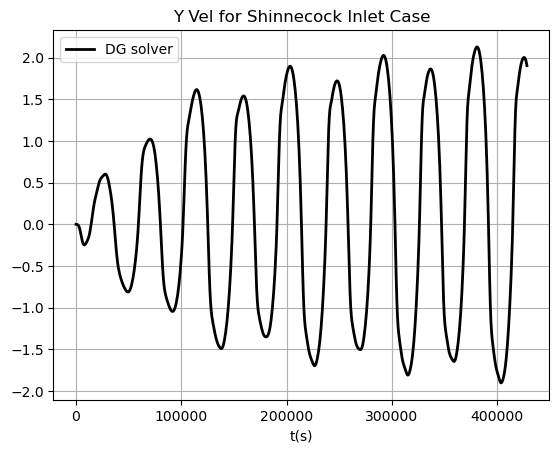

In [7]:
if rank == 0:
        # mannually subtract
        h_b_offset = 2.1845238209
        # solver.vals[:,0,0]=solver.vals[:,0,0]-h_b_offset-bath_adjust

        label = name + " solver"
        plt.plot(
            np.linspace(0, t_f, nt + 1),
            solver.vals[: nt + 1, 0, 0],
            "k",
            linewidth=2,
            label=label,
        )
        plt.plot(
            np.linspace(0, t_f, nt + 1),
            eta_input,
            "bo",
            linewidth=2,
            label="exact data",
        )

        plt.grid(True)
        plt.xlabel("t(s)")
        plt.title("Height for Shinnecock Inlet Case in the middle of the channel.")
        plt.legend()
        
        plt.close()

        plt.plot(
            np.linspace(0, t_f, nt + 1),
            solver.vals[: nt + 1, 0, 1],
            "k",
            linewidth=2,
            label=label,
        )

        plt.grid(True)
        plt.xlabel("t(s)")
        plt.title("X Vel for Shinnecock Inlet Case")
        plt.legend()
        # plt.savefig("shinnecock_xvel_" + f_extension)

        plt.close()

        plt.plot(
            np.linspace(0, t_f, nt + 1),
            solver.vals[: nt + 1, 0, 2],
            "k",
            linewidth=2,
            label=label,
        )

        plt.grid(True)
        plt.xlabel("t(s)")
        plt.title("Y Vel for Shinnecock Inlet Case")
        plt.legend()


In [8]:
import numpy as np
from mpi4py import MPI
import dolfinx.plot as plot
from dolfinx.fem import Function
try:
    import pyvista
except ModuleNotFoundError:
    print("pyvista is required for this demo")
    exit(0)

# If environment variable PYVISTA_OFF_SCREEN is set to true save a png
# otherwise create interactive plot
if pyvista.OFF_SCREEN:
    pyvista.start_xvfb(wait=0.1)

# Set some global options for all plots
transparent = False
figsize = 800

def plot_mixed_function_enhanced(msh, V, u, component=0, title="Mixed function space visualization", 
                               stations=None, cmap='viridis', style='modern'):
    """
    Enhanced plot of a mixed function space component with improved visual appeal
    
    Parameters:
    - msh: The mesh
    - V: Mixed function space
    - u: Function in the mixed space
    - component: Which component of the mixed space to plot (default: 0)
    - title: Plot title
    - stations: Array of station coordinates to plot as red dots (Nx3 array)
    - cmap: Colormap for the contour plot (default: 'viridis')
    - style: Visual style ('modern', 'minimal', 'scientific')
    """
    
    # For mixed function spaces, we need to extract the subspace for plotting
    V_sub = V.sub(component)
    V_sub_collapsed, sub_map = V_sub.collapse()
    
    # Create a function in the collapsed subspace
    u_sub = Function(V_sub_collapsed)
    u_sub.x.array[:] = u.x.array[sub_map]
    
    # Now create the VTK mesh using the collapsed subspace
    cells, types, x = plot.vtk_mesh(V_sub_collapsed)
    grid = pyvista.UnstructuredGrid(cells, types, x)
    
    # Add the function data
    grid.point_data["u"] = u_sub.x.array
    grid.set_active_scalars("u")
    
    # Create plotter with enhanced settings
    if style == 'modern':
        plotter = pyvista.Plotter(window_size=[1200, 900])  # Higher resolution
        plotter.set_background('white')  # Clean white background
    elif style == 'minimal':
        plotter = pyvista.Plotter(window_size=[1000, 800])
        plotter.set_background('#f8f9fa')  # Light gray background
    else:  # scientific
        plotter = pyvista.Plotter(window_size=[1200, 900])
        plotter.set_background('white')
    
    # Enhanced title with better positioning and styling
    plotter.add_text(f"Component {component} - {title}", 
                    font_size=16, 
                    color="black", 
                    position="upper_edge",
                    font='arial',  # Better font
                    shadow=True)
    
    # Enhanced scalar bar with improved styling
    if style == 'modern':
        sargs = dict(
            height=0.08,
            width=0.6,
            vertical=False,
            position_x=0.2,
            position_y=0.02,
            fmt="%.2e",
            title_font_size=14,
            label_font_size=11,
            color="black",
            bold=True,
            title="Magnitude",
            shadow=True,
            n_labels=5,
            font_family='arial'
        )
    elif style == 'minimal':
        sargs = dict(
            height=0.06,
            width=0.5,
            vertical=False,
            position_x=0.25,
            position_y=0.02,
            fmt="%.1e",
            title_font_size=12,
            label_font_size=10,
            color="#333333",
            bold=False,
            title="",  # No title for minimal style
            shadow=False,
            n_labels=3
        )
    else:  # scientific
        sargs = dict(
            height=0.1,
            width=0.7,
            vertical=False,
            position_x=0.15,
            position_y=0.05,
            fmt="%.3e",
            title_font_size=14,
            label_font_size=12,
            color="black",
            bold=True,
            title="Field Value",
            shadow=True,
            n_labels=7
        )
    
    # Enhanced mesh rendering with better visual quality
    if style == 'modern':
        plotter.add_mesh(grid, 
                        show_edges=True, 
                        edge_color='gray',
                        edge_opacity=0.3,
                        line_width=0.5,
                        show_scalar_bar=True, 
                        cmap=cmap, 
                        scalar_bar_args=sargs,
                        smooth_shading=True,  # Smoother surface
                        opacity=0.95)  # Slight transparency
    elif style == 'minimal':
        plotter.add_mesh(grid, 
                        show_edges=False,  # No edges for clean look
                        show_scalar_bar=True, 
                        cmap=cmap, 
                        scalar_bar_args=sargs,
                        smooth_shading=True)
    else:  # scientific
        plotter.add_mesh(grid, 
                        show_edges=True, 
                        edge_color='black',
                        edge_opacity=0.4,
                        line_width=0.8,
                        show_scalar_bar=True, 
                        cmap=cmap, 
                        scalar_bar_args=sargs,
                        smooth_shading=False)  # Keep sharp edges for scientific accuracy
    
    # Enhanced station points with better visibility
    if stations is not None:
        station_points = pyvista.PolyData(stations)
        
        if style == 'modern':
            plotter.add_mesh(station_points, 
                           color='crimson', 
                           point_size=12,
                           render_points_as_spheres=True, 
                           name='stations',
                           ambient=0.3,
                           diffuse=0.7,
                           specular=0.3)
        
        elif style == 'minimal':
            plotter.add_mesh(station_points, 
                           color='red', 
                           point_size=8,
                           render_points_as_spheres=True, 
                           name='stations')
        
        else:  # scientific
            plotter.add_mesh(station_points, 
                           color='red', 
                           point_size=10,
                           render_points_as_spheres=True, 
                           name='stations')
            
            # Add coordinate text for scientific precision
            for i, station in enumerate(stations):
                coord_text = f'({station[0]:.0f}, {station[1]:.0f})'
                plotter.add_point_labels([station], [coord_text], 
                                       point_size=6, 
                                       font_size=8)
    
    # Enhanced camera and lighting
    if style == 'modern':
        # Add subtle lighting for depth
        plotter.add_light(pyvista.Light(position=(1, 1, 1), intensity=0.3))
        plotter.add_light(pyvista.Light(position=(-1, -1, 1), intensity=0.1))
        
        # Better camera positioning
        plotter.camera.elevation = 30
        plotter.camera.azimuth = 45
        
    elif style == 'minimal':
        # Minimal lighting, just overhead
        plotter.view_xy()
        
    else:  # scientific
        # Standard scientific view
        plotter.view_xy()
        plotter.add_light(pyvista.Light(position=(0, 0, 1), intensity=0.2))
    
    # Add optional grid or axes
    if style == 'scientific':
        plotter.show_axes()
        plotter.add_axes(interactive=True)
    
    # Enhanced output settings
    if pyvista.OFF_SCREEN:
        plotter.screenshot(
            f"enhanced_mixed_function_component_{component}_{style}.png",
            transparent_background=transparent,
            window_size=[1600, 1200],  # Higher resolution output
            return_img=False
        )
    else:
        # Add interactivity hints
        if style == 'modern':
            plotter.add_text("Left click + drag: rotate | Right click + drag: pan | Scroll: zoom", 
                           position="lower_edge", font_size=10, color="gray")
        
        plotter.show()
    
    return plotter

# Additional utility function for comparison plots
def plot_comparison(msh, V, u_list, component=0, titles=None, stations=None, cmap='viridis'):
    """
    Plot multiple solutions side by side for comparison
    """
    n_plots = len(u_list)
    plotter = pyvista.Plotter(shape=(1, n_plots), window_size=[400*n_plots, 400])
    
    for i, u in enumerate(u_list):
        plotter.subplot(0, i)
        
        # Extract subspace and function
        V_sub = V.sub(component)
        V_sub_collapsed, sub_map = V_sub.collapse()
        u_sub = Function(V_sub_collapsed)
        u_sub.x.array[:] = u.x.array[sub_map]
        
        # Create mesh
        cells, types, x = plot.vtk_mesh(V_sub_collapsed)
        grid = pyvista.UnstructuredGrid(cells, types, x)
        grid.point_data["u"] = u_sub.x.array
        grid.set_active_scalars("u")
        
        # Plot
        title = titles[i] if titles and i < len(titles) else f"Solution {i+1}"
        plotter.add_text(title, font_size=12)
        
        sargs = dict(height=0.8, width=0.1, vertical=True, 
                    position_x=0.85, position_y=0.1, fmt="%.1e")
        
        plotter.add_mesh(grid, show_edges=True, cmap=cmap, 
                        scalar_bar_args=sargs if i == n_plots-1 else None,
                        show_scalar_bar=i == n_plots-1)
        
        # Add stations
        if stations is not None:
            station_points = pyvista.PolyData(stations)
            plotter.add_mesh(station_points, color='red', point_size=8,
                           render_points_as_spheres=True)
        
        plotter.view_xy()
    
    plotter.show()
    return plotter

[]

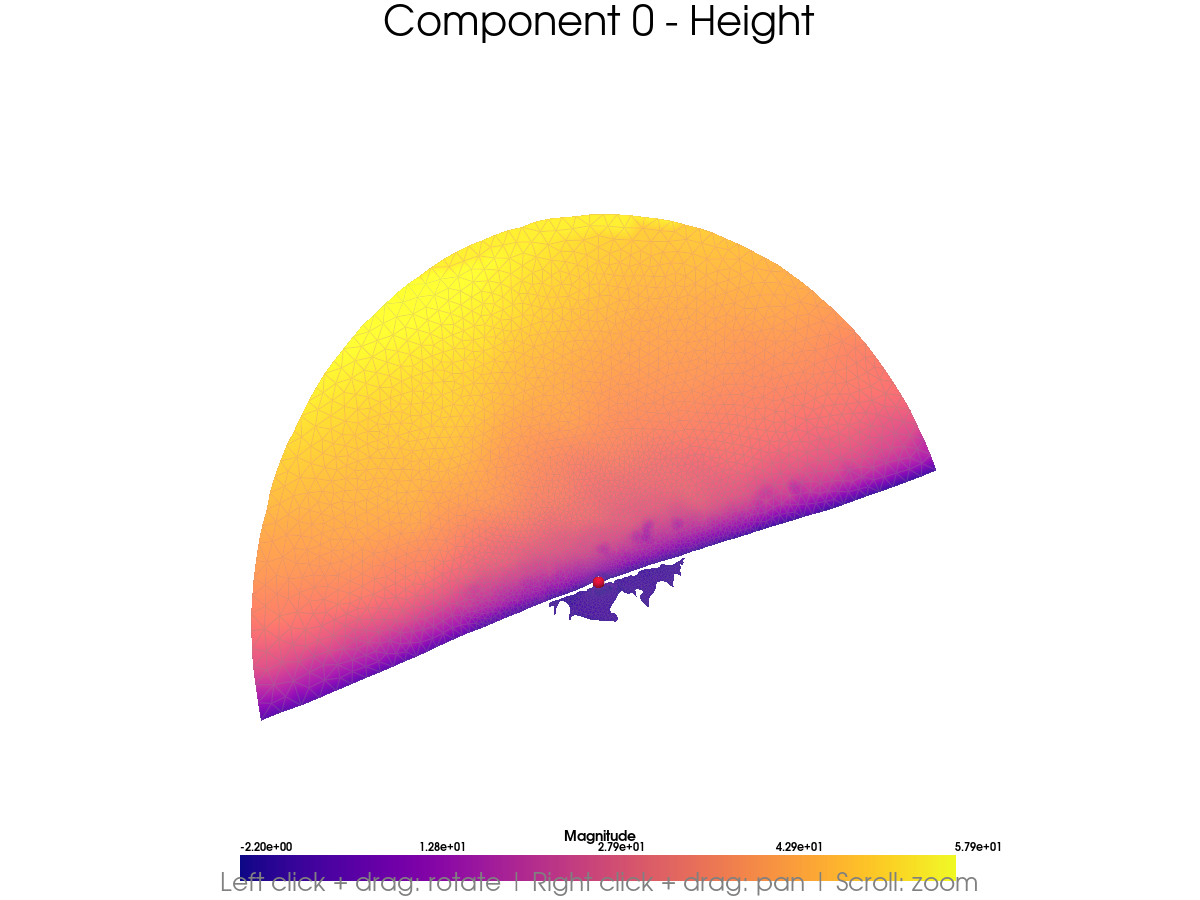

In [8]:
plot_mixed_function_enhanced(prob.mesh,
                    solver.V,
                    solver.u,
                    component=0,
                    title="Height",
                    stations=stations,
                    cmap='plasma',
                    style='modern'
                    )

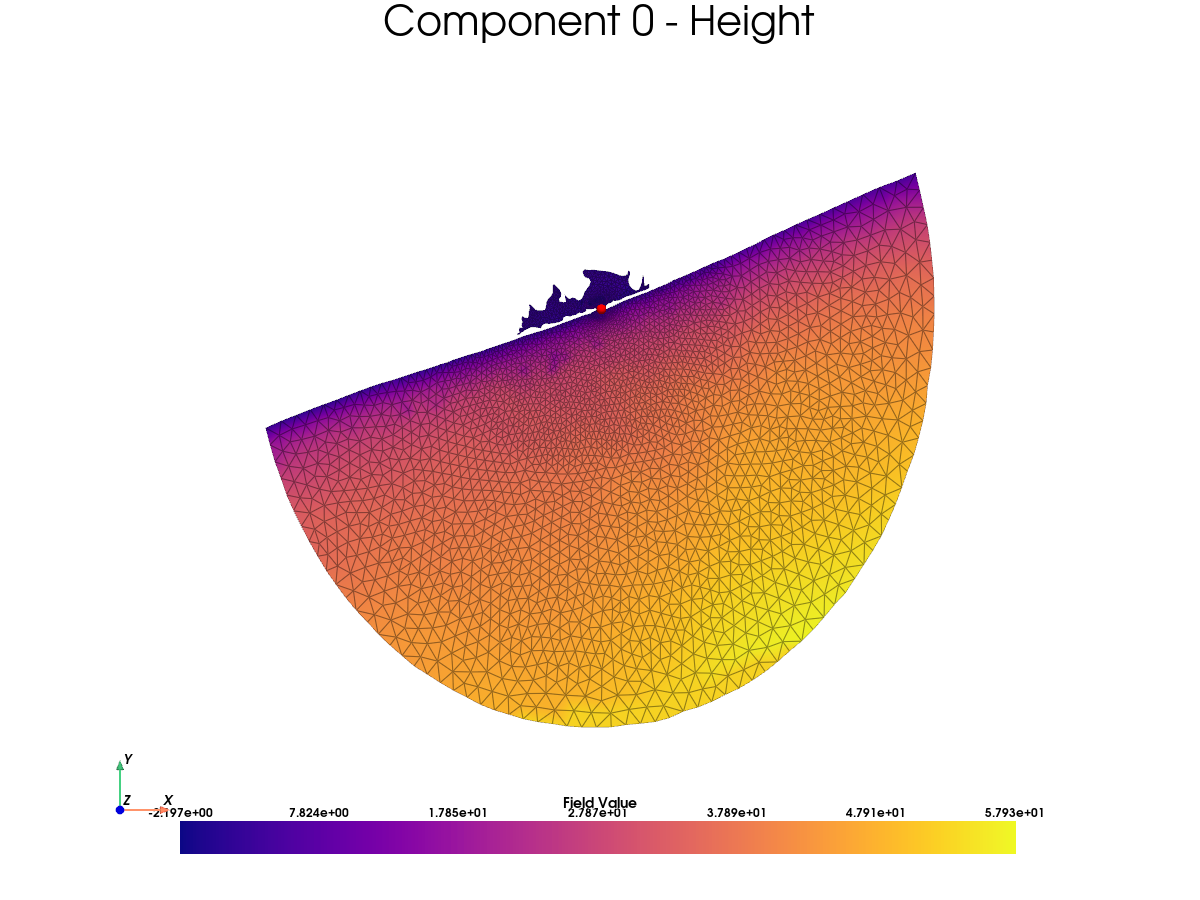

In [9]:
plot_mixed_function_enhanced(prob.mesh,
                    solver.V,
                    solver.u,
                    component=0,
                    title="Height",
                    stations=stations,
                    cmap='plasma',
                    style='scientific'
                    )